# RQ1: Domain-informed causal graph assessment

This notebook processes CodeQL, CogniCrypt, CryptoGuard, and Semgrep separately. It constructs the reporting-policy data, runs association checks, renders one tool-specific causal graph for each dataset, and writes all result artifacts. The graph structure comes from domain knowledge; association statistics are displayed as empirical evidence and do not orient the edges.

## 1. Imports and repository paths

In [1]:
from __future__ import annotations

import hashlib
import importlib.metadata
import json
import platform
import sys
from dataclasses import asdict
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from IPython.display import SVG, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'causal_analysis').exists():
    candidates = [parent for parent in Path.cwd().resolve().parents if (parent / 'causal_analysis').exists()]
    if not candidates:
        raise RuntimeError('Run this notebook from the ci4security repository root.')
    REPO_ROOT = candidates[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from causal_analysis.shared.association_tests import run_association_checks
from causal_analysis.shared.data_loading import load_reporting_policy_data
from causal_analysis.shared.graph_construction import CAUSAL_EDGES, build_causal_graph, render_causal_graph

RQ1_ROOT = REPO_ROOT / 'causal_analysis' / 'rq1_graph_assessment'
CONFIG_ROOT = RQ1_ROOT / 'configs'
GRAPH_ROOT = RQ1_ROOT / 'graphs'
RESULTS_ROOT = RQ1_ROOT / 'results'
TOOLS = ('codeql', 'cognicrypt', 'cryptoguard', 'semgrep')
TOOL_NAMES = {'codeql': 'CodeQL', 'cognicrypt': 'CogniCrypt', 'cryptoguard': 'CryptoGuard', 'semgrep': 'Semgrep'}
ALPHA = 0.06
print('Repository:', REPO_ROOT)
print('Tools:', ', '.join(TOOLS))

Repository: /Users/mkhan04/Desktop/projects/CauSec/ci4security
Tools: codeql, cognicrypt, cryptoguard, semgrep


## 2. Define the common domain-specified graph structure

The same variable roles and directed edges are used systematically for all four tools. Tool-specific correlations are reported in the result tables rather than placed on the graph.

In [2]:
causal_graph = build_causal_graph()
print('Nodes:', list(causal_graph.nodes))
print('Domain-specified edges:')
for source, target in CAUSAL_EDGES:
    print(f'  {source} -> {target}')

Nodes: ['app_popularity_encoded', 'apk_size_scaled', 'reporting_policy', 'reported_alert_is_third_party', 'verdict']
Domain-specified edges:
  app_popularity_encoded -> apk_size_scaled
  app_popularity_encoded -> reported_alert_is_third_party
  app_popularity_encoded -> verdict
  apk_size_scaled -> reported_alert_is_third_party
  apk_size_scaled -> verdict
  reporting_policy -> reported_alert_is_third_party
  reporting_policy -> verdict
  reported_alert_is_third_party -> verdict


## 3. Reproducible output helpers

In [3]:
def sha256(path: Path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()


def package_version(name: str):
    try:
        return importlib.metadata.version(name)
    except importlib.metadata.PackageNotFoundError:
        return 'not-installed'


def policy_summary(data: pd.DataFrame):
    return (
        data.groupby(['reporting_policy', 'reporting_scope'], as_index=False)
        .agg(
            alert_rows=('verdict', 'size'),
            unique_source_alerts=('source_alert_id', 'nunique'),
            true_positive_alerts=('verdict', 'sum'),
            apk_count=('apk_id', 'nunique'),
            precision=('verdict', 'mean'),
        )
        .sort_values('reporting_policy')
    )


def causal_graph_text(tool: str):
    edges = '\n'.join(f'- `{source} -> {target}`' for source, target in CAUSAL_EDGES)
    return f'''# {tool}: RQ1 causal graph

Status: **domain-specified DAG with tool-specific empirical association checks**.

The graph uses `reporting_policy` as the treatment, alert verdict as the outcome, and app popularity and APK size as domain-specified confounders affecting reported alert provenance and verdict. Association results describe empirical compatibility but do not determine arrow direction.

## Edges

{edges}

The tool's Spearman correlations and Benjamini-Hochberg-adjusted significance results are stored separately in `association_checks.csv`. APK-level comparisons and causal-effect estimation are deferred to RQ3.
'''

## 4. Run all four tool datasets separately and write results

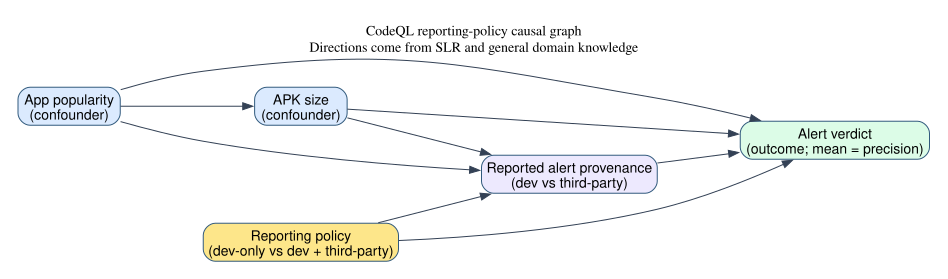

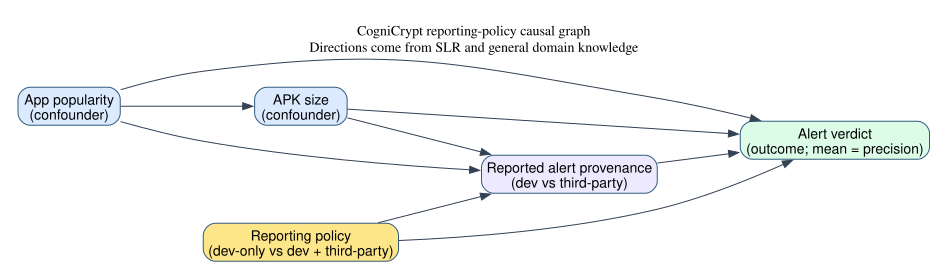

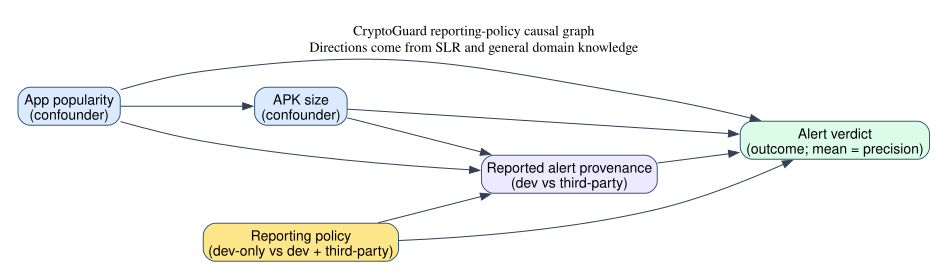

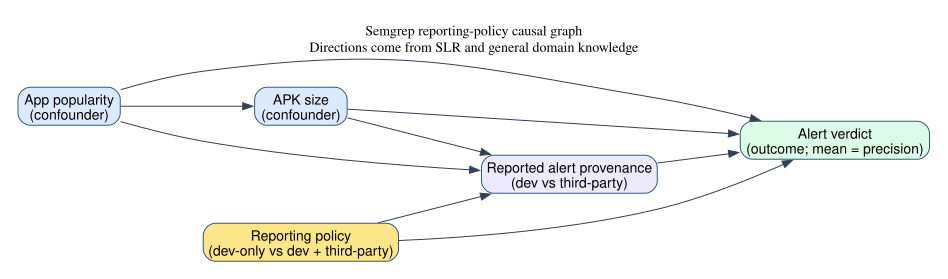

Wrote results for: codeql, cognicrypt, cryptoguard, semgrep


In [4]:
graph_path = GRAPH_ROOT / 'causal_graph.svg'
render_causal_graph('Shared', graph_path)
display(SVG(filename=str(graph_path)))

association_frames = []
policy_frames = []
dataset_rows = []

for tool in TOOLS:
    config = json.loads((CONFIG_ROOT / f'{tool}.json').read_text(encoding='utf-8'))
    data_path = REPO_ROOT / config['data_path']
    output_dir = RESULTS_ROOT / tool
    output_dir.mkdir(parents=True, exist_ok=True)

    data, summary = load_reporting_policy_data(data_path)
    summary_record = {'tool': tool, **asdict(summary)}
    dataset_rows.append(summary_record)
    (output_dir / 'dataset_summary.json').write_text(
        json.dumps(asdict(summary), indent=2) + '\n', encoding='utf-8'
    )

    policies = policy_summary(data)
    policies.insert(0, 'tool', tool)
    policies.to_csv(output_dir / 'reporting_policy_summary.csv', index=False)
    policy_frames.append(policies)

    associations = run_association_checks(data, alpha=ALPHA)
    associations.insert(0, 'tool', tool)
    associations.to_csv(output_dir / 'association_checks.csv', index=False)
    association_frames.append(associations)

    (output_dir / 'causal_graph.md').write_text(causal_graph_text(tool), encoding='utf-8')
    metadata = {
        'tool': tool,
        'run_utc': datetime.now(timezone.utc).isoformat(),
        'source_csv': str(data_path.relative_to(REPO_ROOT)),
        'source_sha256': sha256(data_path),
        'alpha': ALPHA,
        'graph_file': str(graph_path.relative_to(REPO_ROOT)),
        'graph_edges': [list(edge) for edge in CAUSAL_EDGES],
        'graph_method': 'common domain-specified structure; associations reported separately',
        'association_role': 'empirical edge evidence only; directions remain domain-determined',
        'python': platform.python_version(),
        'packages': {name: package_version(name) for name in ('pandas', 'scipy', 'networkx')},
    }
    (output_dir / 'run_metadata.json').write_text(
        json.dumps(metadata, indent=2) + '\n', encoding='utf-8'
    )

all_associations = pd.concat(association_frames, ignore_index=True)
all_policies = pd.concat(policy_frames, ignore_index=True)
all_datasets = pd.DataFrame(dataset_rows)
all_associations.to_csv(RESULTS_ROOT / 'all_tools_association_checks.csv', index=False)
all_policies.to_csv(RESULTS_ROOT / 'all_tools_reporting_policy_summary.csv', index=False)
all_datasets.to_csv(RESULTS_ROOT / 'all_tools_dataset_summary.csv', index=False)
print('Wrote results for:', ', '.join(TOOLS))

## 5. Results overview

The following tables are also saved under `results/`. Raw policy-arm differences are descriptive; later RQ3 estimators provide the causal estimates.

In [5]:
display(all_datasets)
display(all_policies)
display(
    all_associations[[
        'tool', 'variable_1', 'variable_2', 'test', 'effect_size',
        'p_value', 'q_value_bh', 'associated_at_alpha'
    ]]
)

,tool,raw_alerts,analyzed_alert_rows,developer_alerts,third_party_alerts,apks
0,codeql,21501,22055,554,20947,488
1,cognicrypt,5675,6173,498,5177,324
2,cryptoguard,15272,16590,1318,13954,354
3,semgrep,14590,16350,1760,12830,535


,tool,reporting_policy,reporting_scope,alert_rows,unique_source_alerts,true_positive_alerts,apk_count,precision
0,codeql,0,developer_only,554,554,527,153,0.951264
1,codeql,1,developer_plus_third_party,21501,21501,19107,488,0.888656
2,cognicrypt,0,developer_only,498,498,349,90,0.700803
3,cognicrypt,1,developer_plus_third_party,5675,5675,2750,324,0.484581
4,cryptoguard,0,developer_only,1318,1318,676,166,0.512898
5,cryptoguard,1,developer_plus_third_party,15272,15272,7357,354,0.481731
6,semgrep,0,developer_only,1760,1760,967,256,0.549432
7,semgrep,1,developer_plus_third_party,14590,14590,9838,535,0.674297


,tool,variable_1,variable_2,test,effect_size,p_value,q_value_bh,associated_at_alpha
0,codeql,app_popularity_encoded,apk_size_scaled,spearman_two_sided,0.432622,0.000000e+00,0.000000e+00,True
1,codeql,app_popularity_encoded,reporting_policy,spearman_two_sided,0.021099,1.726913e-03,2.110671e-03,True
2,codeql,app_popularity_encoded,verdict,spearman_two_sided,0.050291,7.843369e-14,2.156927e-13,True
3,codeql,apk_size_scaled,reporting_policy,spearman_two_sided,0.006617,3.257910e-01,3.257910e-01,False
4,codeql,apk_size_scaled,verdict,spearman_two_sided,-0.030510,5.847896e-06,9.189550e-06,True
5,codeql,reporting_policy,verdict,spearman_two_sided,-0.031341,3.236000e-06,5.932667e-06,True
6,codeql,reporting_policy,reported_alert_is_third_party,spearman_two_sided,0.697938,0.000000e+00,0.000000e+00,True
7,codeql,app_popularity_encoded,reported_alert_is_third_party,spearman_two_sided,0.030231,7.112654e-06,9.779899e-06,True
8,codeql,apk_size_scaled,reported_alert_is_third_party,spearman_two_sided,0.009481,1.591555e-01,1.750711e-01,False
9,codeql,reported_alert_is_third_party,verdict,spearman_two_sided,-0.044905,2.528144e-11,5.561917e-11,True
